In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = pd.read_csv("Wine.csv")

In [3]:
print(data.head())

   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  Customer_Segment  
0   3.92     1065                 1  
1   3.40     105

In [7]:
print(data.columns)

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline',
       'Customer_Segment'],
      dtype='object')


In [8]:
X = data.drop('Customer_Segment', axis=1)

y = data['Customer_Segment']

# Step 6: Standardize Data

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

 # Step 8: Create PCA DataFrame

In [11]:
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

pca_df['Customer_Segment'] = y

# Step 9: Visualize PCA Graph

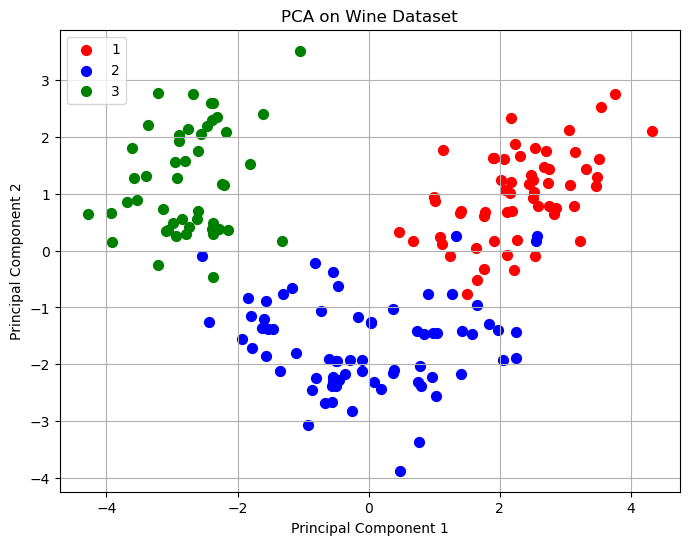

In [12]:
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

targets = pca_df['Customer_Segment'].unique()

for target, color in zip(targets, colors):

    plt.scatter(
        pca_df[pca_df['Customer_Segment'] == target]['PC1'],
        pca_df[pca_df['Customer_Segment'] == target]['PC2'],
        c=color,
        s=50,
        label=target
    )

plt.xlabel('Principal Component 1')

plt.ylabel('Principal Component 2')

plt.title('PCA on Wine Dataset')

plt.legend()

plt.grid()

plt.show()

 # Step 10: Print Explained Variance Ratio

In [13]:
print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.36198848 0.1920749 ]
